# Comparative Evaluation of Machine Learning Techniques for Cardiovascular Risk Prediction

### Machine Learning Case Study

This project evaluates and compares four machine learning algorithms for cardiovascular disease risk prediction across three different datasets:

1. Cardiovascular Disease Dataset
2. Framingham Heart Study Dataset
3. Cleveland Heart Disease Dataset

The algorithms evaluated are:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest

## 1. Introduction

### Problem Statement

Cardiovascular diseases are a major health concern, and machine learning can be used to identify patterns in clinical and health-related data that may help predict cardiovascular disease outcomes.

### Objective

The objective of this case study is to comparatively evaluate multiple machine learning techniques for cardiovascular risk prediction using three different datasets.

Each dataset has its own available features and target definition. The same four machine learning algorithms will be applied to each dataset, while preprocessing and feature engineering will be adapted to the characteristics of the individual dataset.

### Models Compared

The study evaluates four different types of machine learning approaches:

- **Logistic Regression** — linear and probabilistic baseline
- **K-Nearest Neighbors (KNN)** — distance-based, non-parametric model
- **Decision Tree** — interpretable nonlinear model
- **Random Forest** — ensemble tree-based model

### Evaluation

Model performance will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Confusion matrices, ROC curves, model-comparison plots, and Random Forest feature importance will also be used to support the analysis.

The final analysis will compare model performance within each dataset and across the three datasets.

In [31]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from utils import *

In [2]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## 2. Load Datasets

Three cardiovascular-related datasets are used in this study:

1. **Cardiovascular Disease Dataset**
   - File: `cardio_train.csv`
   - Target: `cardio`

2. **Framingham Heart Study Dataset**
   - File: `framingham.csv`
   - Target: `TenYearCHD`

3. **Cleveland Heart Disease Dataset**
   - File: `heart_disease_cleveland.csv`
   - Target: `target`

The datasets contain different features and target definitions. Each dataset will therefore be processed according to its own characteristics rather than being forced into a common feature set.

In [4]:
# Dataset 1 — Cardiovascular Disease
cardio_df = pd.read_csv("data/cardio_train.csv")

# Dataset 2 — Framingham Heart Study
framingham_df = pd.read_csv("data/framingham.csv")

# Dataset 3 — Cleveland Heart Disease
cleveland_df = pd.read_csv("data/heart_disease_cleveland.csv")

In [5]:
print("Cardiovascular Disease Dataset:", cardio_df.shape)
print("Framingham Dataset:", framingham_df.shape)
print("Cleveland Heart Disease Dataset:", cleveland_df.shape)

Cardiovascular Disease Dataset: (70000, 13)
Framingham Dataset: (4240, 16)
Cleveland Heart Disease Dataset: (303, 14)


## 3. Dataset Inspection

Before preprocessing, each dataset is inspected to understand its structure, feature types, missing values, duplicate records, descriptive statistics, and target distribution.

This initial inspection will guide the dataset-specific preprocessing and feature engineering decisions.

In [6]:
print("First 5 rows:")
display(cardio_df.head())

print("\nDataset information:")
cardio_df.info()

print("\nDescriptive statistics:")
display(cardio_df.describe())

print("\nMissing values:")
display(cardio_df.isnull().sum())

print("\nDuplicate rows:", cardio_df.duplicated().sum())

print("\nTarget distribution:")
display(cardio_df["cardio"].value_counts())

First 5 rows:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB

Descriptive statistics:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000



Missing values:


id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


Duplicate rows: 0

Target distribution:


cardio
0    35021
1    34979
Name: count, dtype: int64

In [7]:
print("First 5 rows:")
display(framingham_df.head())

print("\nDataset information:")
framingham_df.info()

print("\nDescriptive statistics:")
display(framingham_df.describe())

print("\nMissing values:")
display(framingham_df.isnull().sum())

print("\nDuplicate rows:", framingham_df.duplicated().sum())

print("\nTarget distribution:")
display(framingham_df["TenYearCHD"].value_counts())

First 5 rows:


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB

D

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000



Missing values:


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


Duplicate rows: 0

Target distribution:


TenYearCHD
0    3596
1     644
Name: count, dtype: int64

In [8]:
print("First 5 rows:")
display(cleveland_df.head())

print("\nDataset information:")
cleveland_df.info()

print("\nDescriptive statistics:")
display(cleveland_df.describe())

print("\nMissing values:")
display(cleveland_df.isnull().sum())

print("\nDuplicate rows:", cleveland_df.duplicated().sum())

print("\nTarget distribution:")
display(cleveland_df["target"].value_counts())

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Descriptive statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000



Missing values:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


Duplicate rows: 0

Target distribution:


target
0    164
1    139
Name: count, dtype: int64

## 4. Dataset 1 — Cardiovascular Disease

The Cardiovascular Disease dataset contains demographic, physical, lifestyle, and clinical measurements.

The target variable is `cardio`, which represents the presence or absence of cardiovascular disease.

Before preprocessing, we explore the target distribution, feature distributions, relationships between categorical variables and the target, correlations among numerical features, and potential outliers.

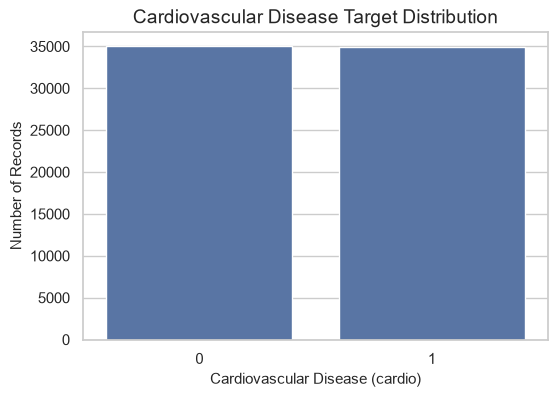

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=cardio_df,
    x="cardio"
)

plt.title("Cardiovascular Disease Target Distribution")
plt.xlabel("Cardiovascular Disease (cardio)")
plt.ylabel("Number of Records")

plt.show()

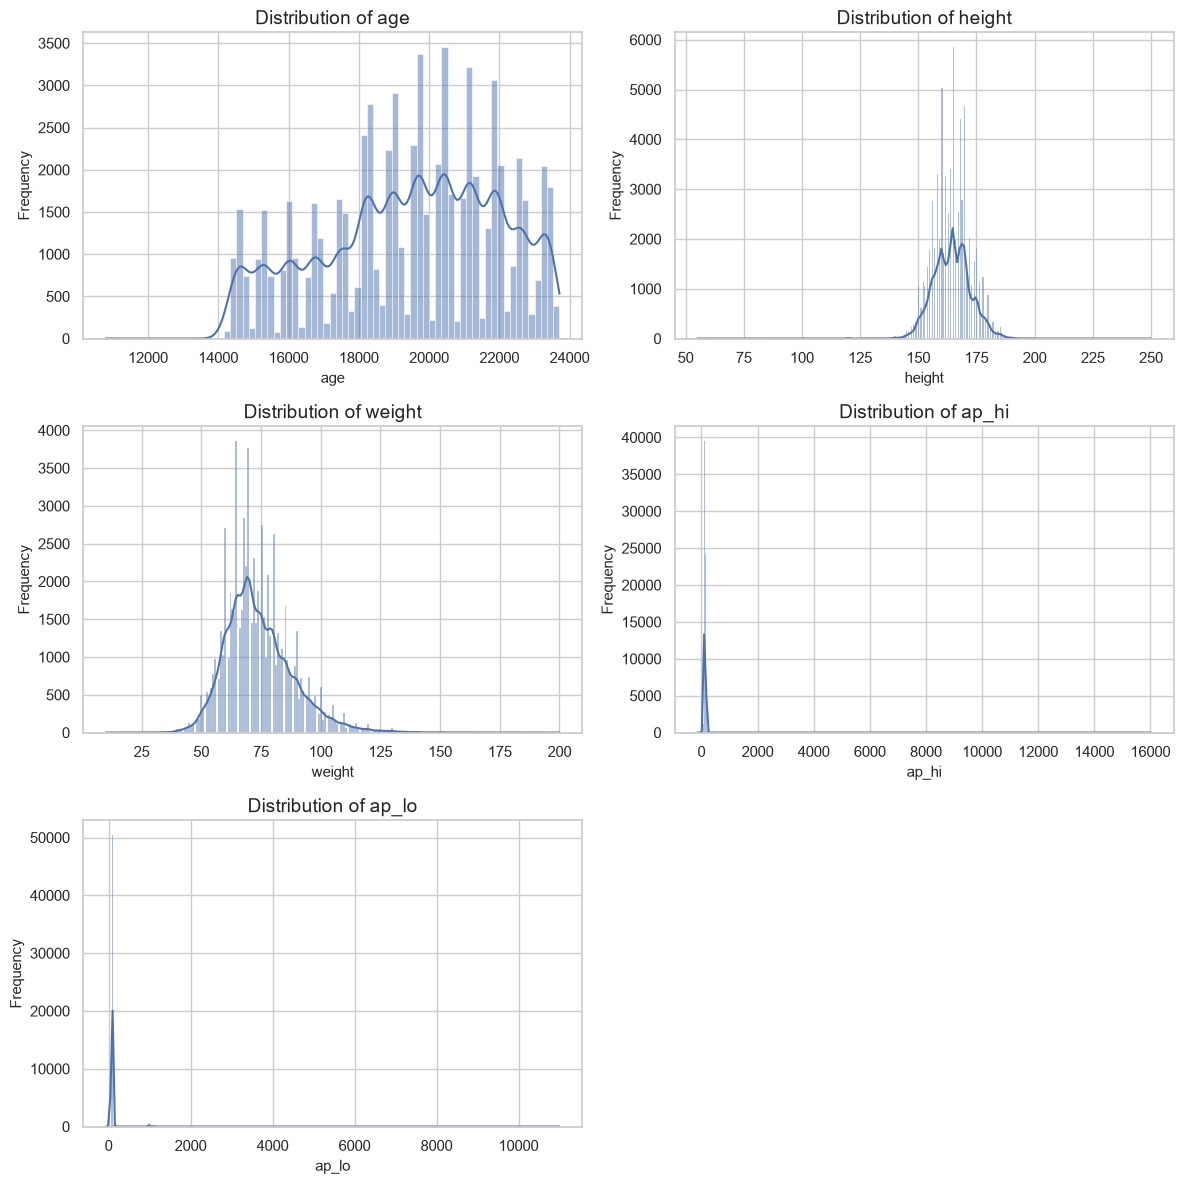

In [10]:
numerical_features_d1 = [
    "age",
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]

fig, axes = plt.subplots(
    3, 2,
    figsize=(12, 12)
)

axes = axes.flatten()

for i, feature in enumerate(numerical_features_d1):
    sns.histplot(
        data=cardio_df,
        x=feature,
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

# Hide unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

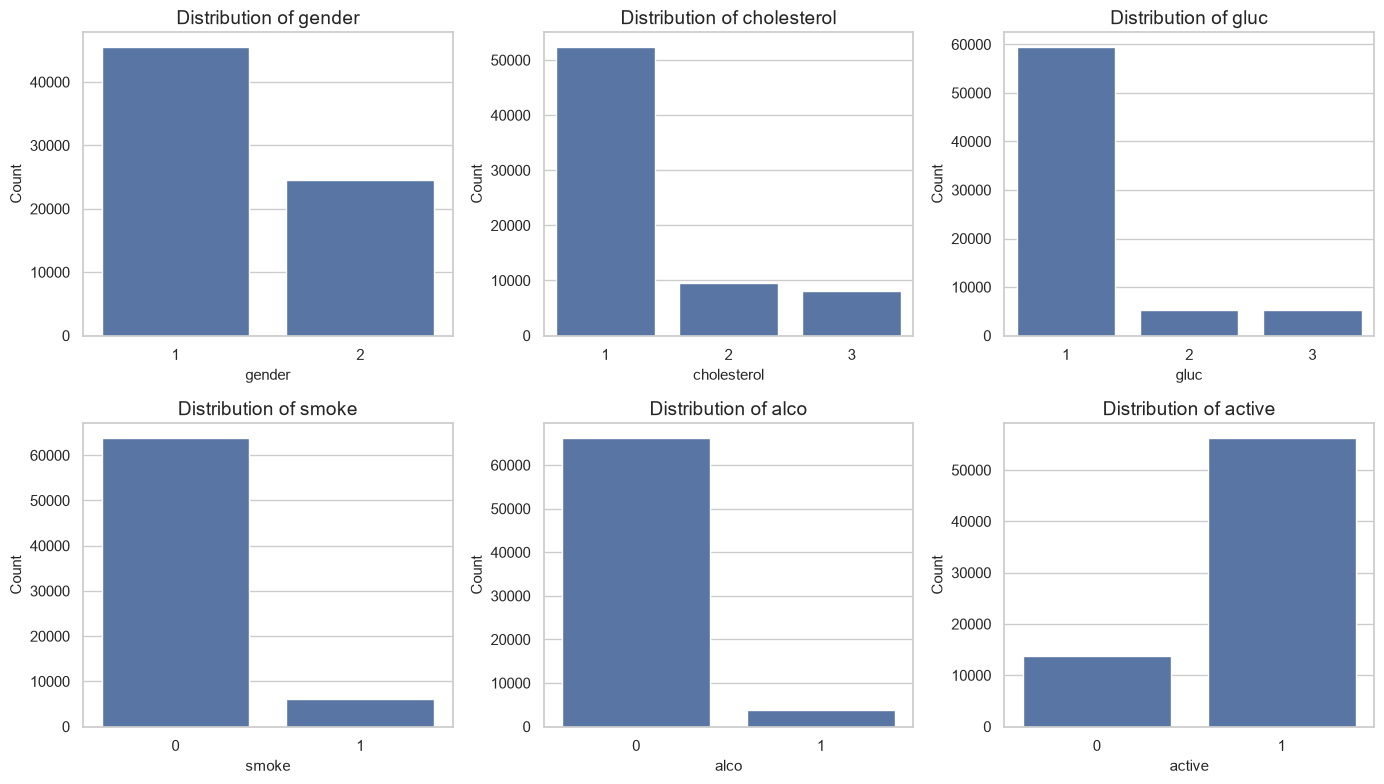

In [11]:
categorical_features_d1 = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 8)
)

axes = axes.flatten()

for i, feature in enumerate(categorical_features_d1):
    sns.countplot(
        data=cardio_df,
        x=feature,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

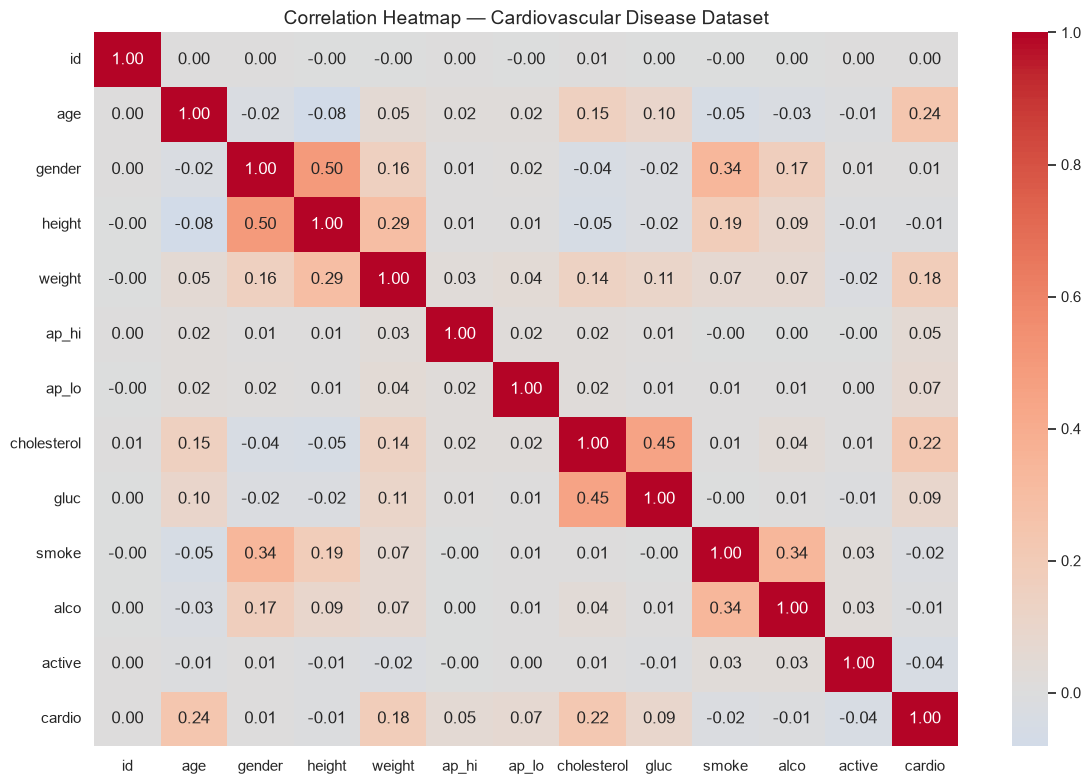

In [12]:
plt.figure(figsize=(12, 8))

correlation_d1 = cardio_df.corr(numeric_only=True)

sns.heatmap(
    correlation_d1,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap — Cardiovascular Disease Dataset")
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

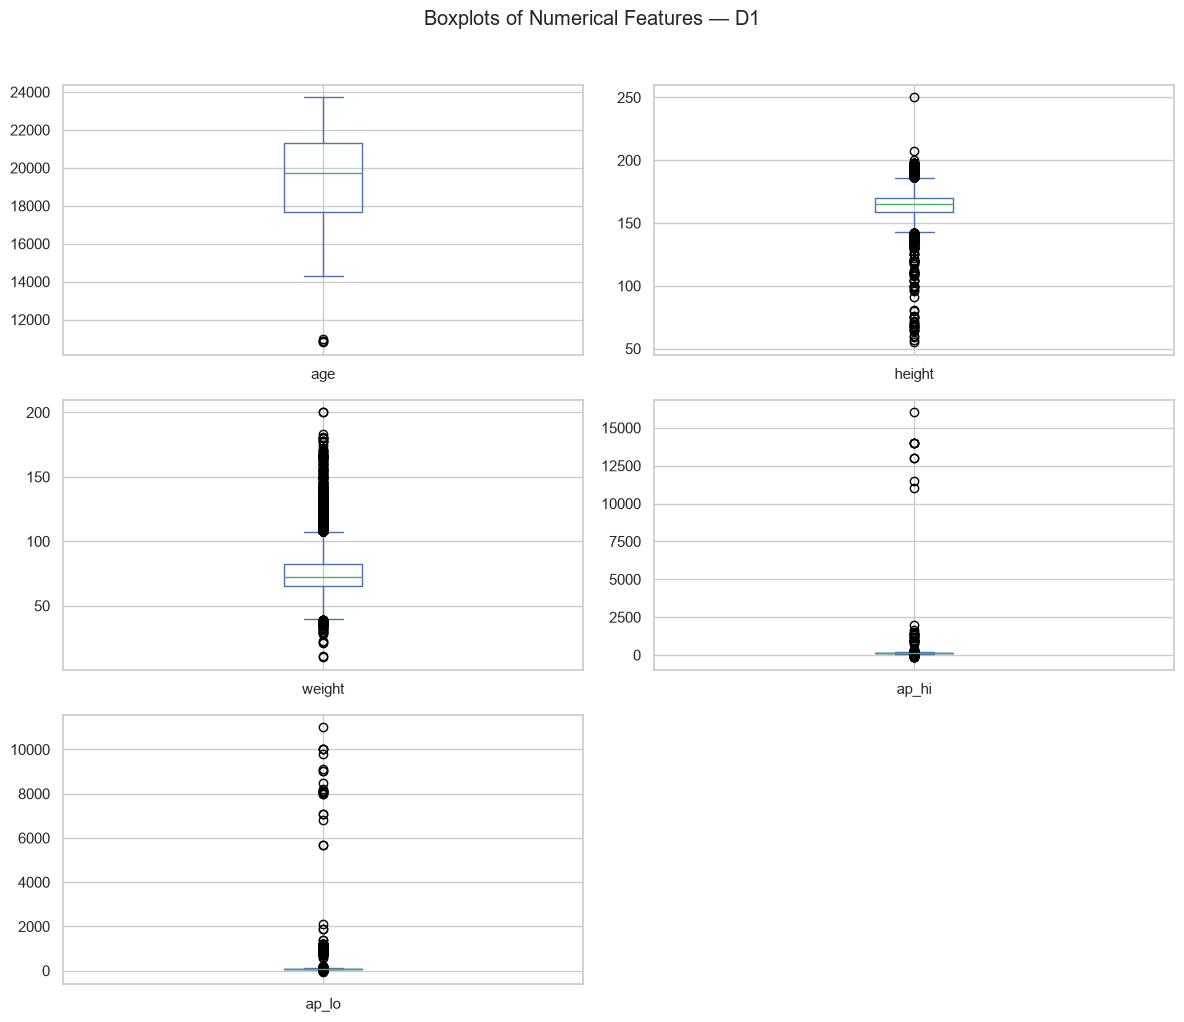

In [13]:
plt.figure(figsize=(12, 8))

cardio_df[numerical_features_d1].plot(
    kind="box",
    subplots=True,
    layout=(3, 2),
    figsize=(12, 10),
    sharex=False,
    sharey=False
)

plt.suptitle("Boxplots of Numerical Features — D1", y=1.02)
plt.tight_layout()
plt.show()

### D1 Feature Engineering

The Cardiovascular Disease dataset stores age in days, so it will be converted to years for interpretability.

Three additional features will also be derived from the available measurements:

- **BMI (Body Mass Index)** from height and weight
- **Pulse Pressure** from systolic and diastolic blood pressure
- **Mean Arterial Pressure (MAP)** from systolic and diastolic blood pressure

The original `id` column will be removed because it is an identifier and does not provide meaningful predictive information.

The original `age` column will also be replaced by `age_years`.

In [14]:
# Create a copy so the original loaded dataset remains unchanged
cardio_processed = cardio_df.copy()

# Remove identifier
cardio_processed = cardio_processed.drop(columns=["id"])

# Convert age from days to years
cardio_processed["age_years"] = cardio_processed["age"] / 365.25

# Remove original age column
cardio_processed = cardio_processed.drop(columns=["age"])

# Convert height from cm to metres for BMI calculation
height_m = cardio_processed["height"] / 100

# Calculate BMI
cardio_processed["BMI"] = (
    cardio_processed["weight"] / (height_m ** 2)
)

# Calculate pulse pressure
cardio_processed["pulse_pressure"] = (
    cardio_processed["ap_hi"] - cardio_processed["ap_lo"]
)

# Calculate mean arterial pressure
cardio_processed["MAP"] = (
    cardio_processed["ap_hi"] + 2 * cardio_processed["ap_lo"]
) / 3

In [15]:
print("D1 feature columns:")
print(cardio_processed.columns.tolist())

print("\nDataset shape:")
print(cardio_processed.shape)

print("\nFirst 5 rows:")
display(cardio_processed.head())

D1 feature columns:
['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'BMI', 'pulse_pressure', 'MAP']

Dataset shape:
(70000, 15)

First 5 rows:


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,BMI,pulse_pressure,MAP
0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290,21.967120,30,90.000000
1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246,34.927679,50,106.666667
2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652,23.507805,60,90.000000
3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144,28.710479,50,116.666667
4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205,23.011177,40,73.333333


### D1 Preprocessing

The dataset-specific preprocessing will separate the target variable from the input features and divide the data into training and testing sets.

The preprocessing strategy must account for the different types of variables in the dataset:

- Numerical features will be scaled.
- Binary features will be retained as binary values.
- `cholesterol` and `gluc` are ordinal categorical variables.
- Preprocessing transformations will be fitted only on the training data to prevent data leakage.

A stratified train-test split will be used so that the class distribution of the target is preserved in both subsets.

In [17]:
from sklearn.model_selection import train_test_split

# Separate features and target
X_d1 = cardio_processed.drop(columns=["cardio"])
y_d1 = cardio_processed["cardio"]

# Stratified train-test split
X_train_d1, X_test_d1, y_train_d1, y_test_d1 = train_test_split(
    X_d1,
    y_d1,
    test_size=0.20,
    random_state=42,
    stratify=y_d1
)

print("Training set:", X_train_d1.shape)
print("Test set:", X_test_d1.shape)

print("\nTraining target distribution:")
print(y_train_d1.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test_d1.value_counts(normalize=True))

Training set: (56000, 14)
Test set: (14000, 14)

Training target distribution:
cardio
0    0.500304
1    0.499696
Name: proportion, dtype: float64

Test target distribution:
cardio
0    0.500286
1    0.499714
Name: proportion, dtype: float64


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Numerical features
numerical_features_d1 = [
    "age_years",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "BMI",
    "pulse_pressure",
    "MAP"
]

# Ordinal categorical features
ordinal_features_d1 = [
    "cholesterol",
    "gluc"
]

# Binary features
binary_features_d1 = [
    "gender",
    "smoke",
    "alco",
    "active"
]

# Preprocessing
preprocessor_d1 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_d1),
        ("ordinal", OrdinalEncoder(), ordinal_features_d1),
        ("binary", "passthrough", binary_features_d1)
    ]
)

In [19]:
X_train_d1_processed = preprocessor_d1.fit_transform(X_train_d1)

X_test_d1_processed = preprocessor_d1.transform(X_test_d1)

print("Processed training data shape:", X_train_d1_processed.shape)
print("Processed test data shape:", X_test_d1_processed.shape)

Processed training data shape: (56000, 14)
Processed test data shape: (14000, 14)


## 5. D1 Model Training

Four machine learning algorithms will be trained on the preprocessed Cardiovascular Disease dataset:

1. **Logistic Regression** — linear and probabilistic baseline
2. **K-Nearest Neighbors (KNN)** — distance-based, non-parametric model
3. **Decision Tree** — interpretable nonlinear model
4. **Random Forest** — ensemble tree-based model

The same four algorithms will be used for all three datasets to maintain a consistent experimental methodology.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


models_d1 = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

In [21]:
for model_name, model in models_d1.items():
    model.fit(
        X_train_d1_processed,
        y_train_d1
    )

print("All D1 models trained successfully.")

All D1 models trained successfully.


## 6. D1 Model Evaluation

The trained models will now be evaluated on the unseen test set.

The following metrics will be used:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Accuracy provides an overall measure of correct predictions, while Precision, Recall, and F1-score provide additional information about classification performance. ROC-AUC measures the model's ability to distinguish between the two classes across different classification thresholds.

For cardiovascular risk prediction, Recall, F1-score, and ROC-AUC will receive particular attention because false-negative predictions are important in this context.

In [ ]:
from utils import evaluate_model

d1_results = {}
d1_predictions = {}
d1_probabilities = {}

for model_name, model in models_d1.items():
    metrics, y_pred, y_prob = evaluate_model(
        model,
        X_test_d1_processed,
        y_test_d1
    )

    d1_results[model_name] = metrics
    d1_predictions[model_name] = y_pred
    d1_probabilities[model_name] = y_prob

print("D1 evaluation completed.")

D1 evaluation completed.


In [24]:
d1_results_df = pd.DataFrame(d1_results).T

d1_results_df = d1_results_df[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]

display(d1_results_df.round(4))

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.7134,0.7313,0.6741,0.7015,0.7780
KNN,0.6534,0.6585,0.6365,0.6473,0.6968
Decision Tree,0.6274,0.6289,0.6205,0.6247,0.6274
Random Forest,0.7112,0.7148,0.7024,0.7085,0.7696


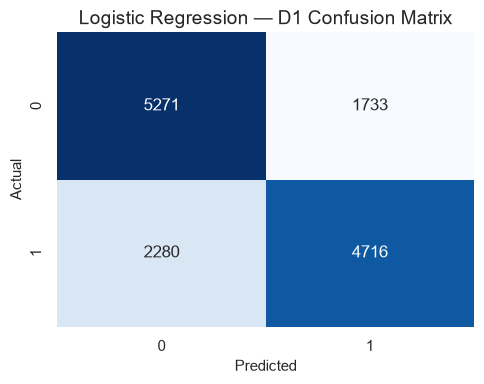

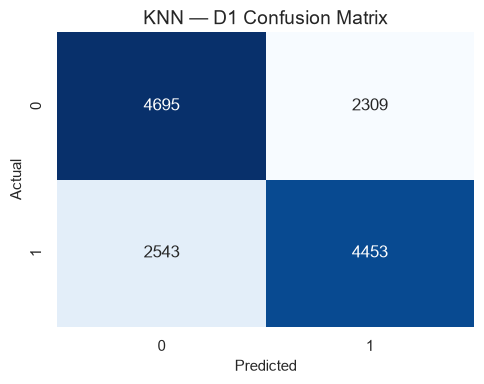

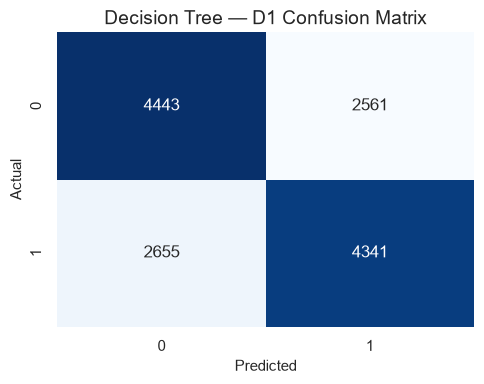

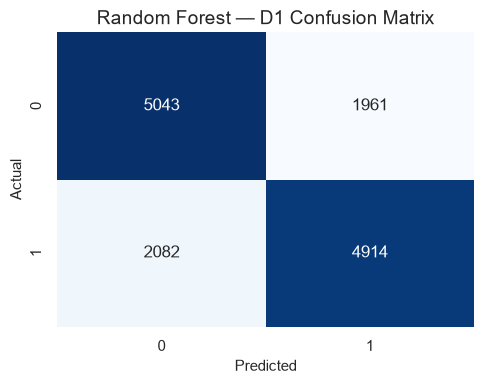

In [32]:
for model_name in models_d1:
    plot_confusion_matrix(
        y_test_d1,
        d1_predictions[model_name],
        title=f"{model_name} — D1 Confusion Matrix"
    )

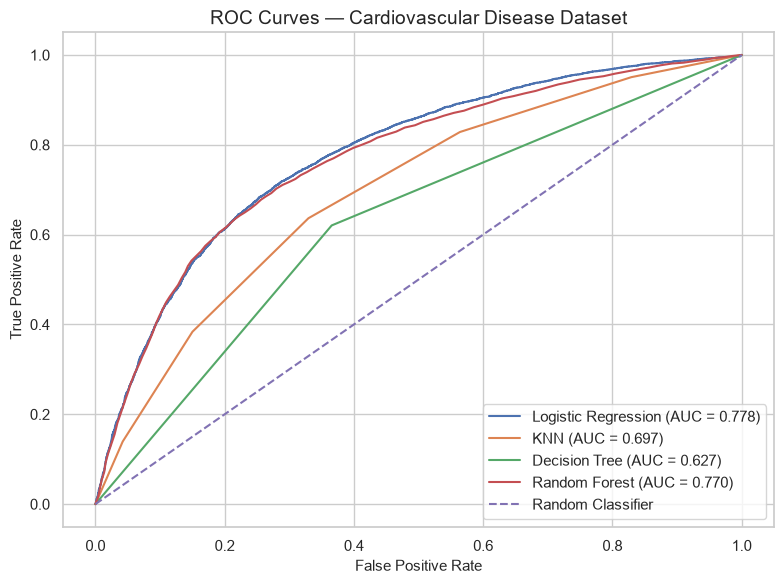

In [33]:
plt.figure(figsize=(8, 6))

for model_name in models_d1:
    plot_roc_curve(
        y_test_d1,
        d1_probabilities[model_name],
        label=model_name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Cardiovascular Disease Dataset")

plt.legend()
plt.tight_layout()
plt.show()

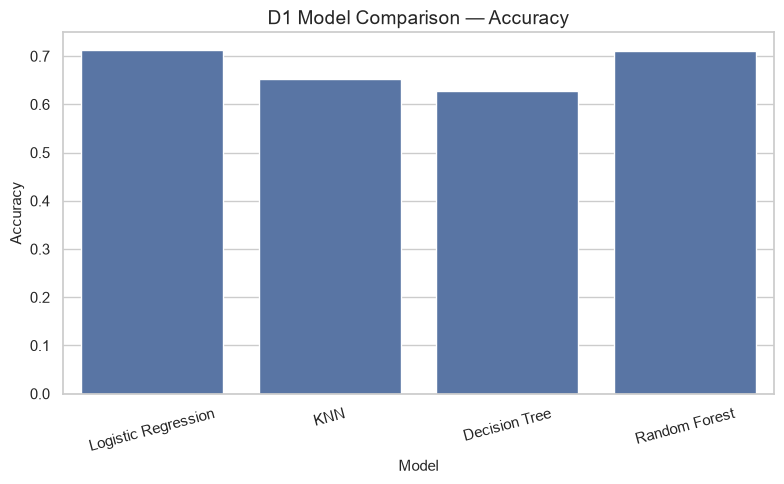

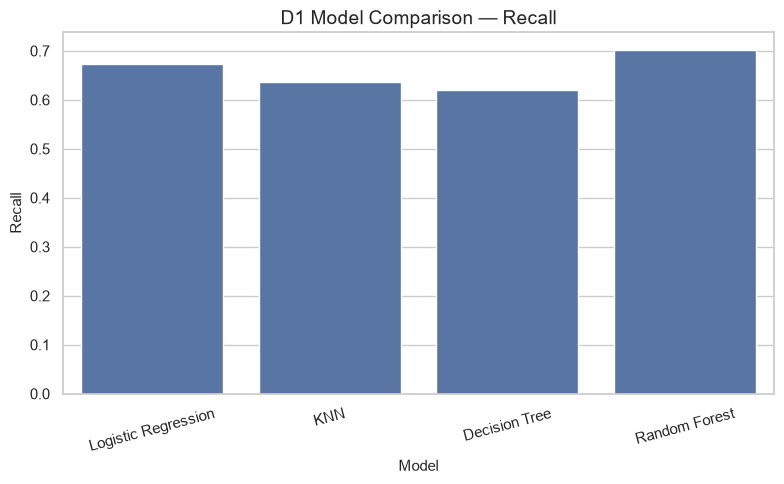

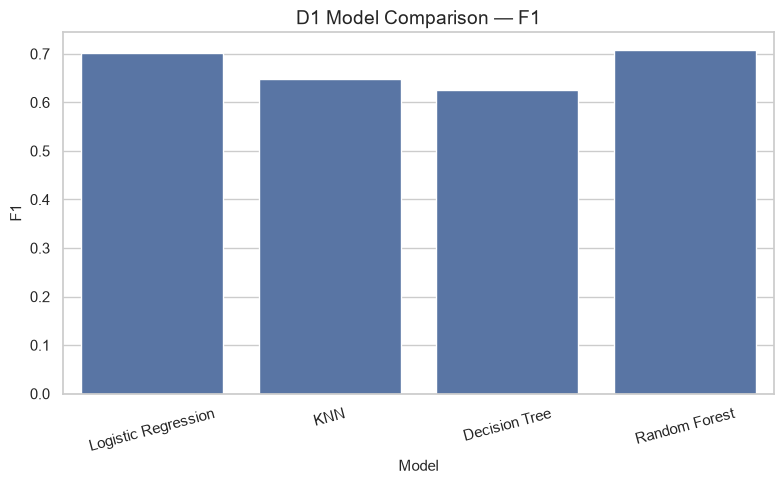

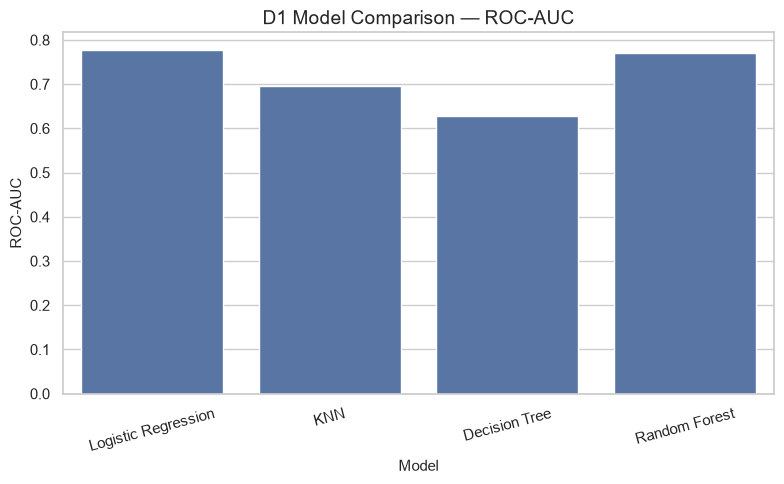

In [34]:
metrics_to_plot = [
    "Accuracy",
    "Recall",
    "F1",
    "ROC-AUC"
]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=d1_results_df.reset_index(),
        x="index",
        y=metric
    )

    plt.title(f"D1 Model Comparison — {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=15)

    plt.tight_layout()
    plt.show()

In [35]:
rf_d1 = models_d1["Random Forest"]

feature_names_d1 = (
    numerical_features_d1
    + ordinal_features_d1
    + binary_features_d1
)

d1_feature_importance = pd.DataFrame({
    "Feature": feature_names_d1,
    "Importance": rf_d1.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

display(d1_feature_importance)

,Feature,Importance
0,age_years,0.252178
5,BMI,0.156101
2,weight,0.116246
1,height,0.110347
7,MAP,0.096283
3,ap_hi,0.084129
6,pulse_pressure,0.047802
4,ap_lo,0.038808
8,cholesterol,0.035664
9,gluc,0.016573


### D1 Results Discussion